| Symbol | Meaning |
|---|---|
| 🏭 | Depot — agent starts here every episode |
| 📦 | Customer node — pending delivery |
| ✅ | Customer node — delivered |
| ⛔ | Obstacle — blocked road |
| 🤖 | Agent (yellow) |

### Reward System
| Event | Points |
|---|---|
| Delivery to customer | +15 |
| All deliveries done (bonus) | +30 |
| New cell explored | +2 |
| Hit obstacle | -5 |
| Left grid boundary | -3 |
| Each step (time cost) | -0.5 |

**The agent runs step-by-step. It stops the moment all 10 deliveries are complete.**

In [1]:
# CELL 1 — Install
!pip install matplotlib numpy pandas pillow -q
print('OK')

OK


In [2]:
# CELL 2 — Imports & constants
import io, time, random
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')          # Must be set BEFORE importing pyplot — fixes Colab blank figure bug
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from IPython.display import display, clear_output, Image as IPImage

# ── grid ──────────────────────────────────────────────────
GRID_SIZE      = 10
N_EPISODES     = 80
MAX_STEPS      = 80

# ── Q-learning ────────────────────────────────────────────
ALPHA          = 0.15
GAMMA          = 0.92
EPS_START      = 1.0
EPS_END        = 0.05
EPS_DECAY      = 0.97

# ── animation ─────────────────────────────────────────────
RENDER_EVERY   = 2      # show every Nth step (1 = every step, slower)
FRAME_SLEEP    = 0.07   # seconds between rendered frames
DONE_SLEEP     = 0.6    # pause when episode finishes

# ── cell types ────────────────────────────────────────────
EMPTY, DEPOT, CUSTOMER, OBSTACLE = 0, 1, 2, 3

AGENT_COLOR = '#FFD700'
print('Constants ready.')

Constants ready.


In [3]:
# CELL 3 — Grid environment
class LogisticsGrid:
    def __init__(self, size=GRID_SIZE):
        self.size  = size
        self.grid  = np.zeros((size, size), dtype=int)
        self.depot = (0, 0)
        self.customers = []
        self.obstacles = []
        self._build()

    def _build(self):
        self.grid[0][0] = DEPOT
        for r, c in [(2,7),(5,5),(8,2),(7,8),(3,3),(9,6),(1,9),(6,1),(4,8),(8,5)]:
            self.grid[r][c] = CUSTOMER
            self.customers.append((r, c))
        for r, c in [(1,3),(2,3),(3,6),(4,4),(5,2),(6,6),(7,3),(7,4),(8,8),(0,5)]:
            if self.grid[r][c] == EMPTY:
                self.grid[r][c] = OBSTACLE
                self.obstacles.append((r, c))

print('Grid ready.')

Grid ready.


In [4]:
# CELL 4 — Agent memory
class AgentMemory:
    def __init__(self):
        self.episodes    = []
        self.rewards     = []
        self.steps       = []
        self.deliveries  = []
        self.best_reward = -1e9
        self.best_route  = None
        self.danger_hits = defaultdict(int)

    def record(self, ep, reward, steps, deliveries, route, dangers):
        self.episodes.append({'episode': ep, 'reward': round(reward,2),
                               'steps': steps, 'deliveries': deliveries,
                               'efficiency': round(deliveries/max(steps,1),4)})
        self.rewards.append(reward)
        self.steps.append(steps)
        self.deliveries.append(deliveries)
        if reward > self.best_reward:
            self.best_reward = reward
            self.best_route  = route[:]
        for d in dangers:
            self.danger_hits[d] += 1

print('Memory ready.')

Memory ready.


In [5]:
# CELL 5 — Q-Learning agent
class LogisticsAgent:
    MOVES = [(-1,0),(1,0),(0,-1),(0,1)]   # N S W E

    def __init__(self, grid: LogisticsGrid):
        self.grid    = grid
        self.memory  = AgentMemory()
        self.Q       = defaultdict(lambda: np.zeros(4))
        self.epsilon = EPS_START

    def _key(self, pos, rem):
        return (pos, frozenset(rem))

    def _act(self, key):
        return random.randint(0,3) if random.random() < self.epsilon \
               else int(np.argmax(self.Q[key]))

    def _transition(self, pos, a, rem, vis):
        dr, dc = self.MOVES[a]
        nr, nc = pos[0]+dr, pos[1]+dc
        if not (0 <= nr < self.grid.size and 0 <= nc < self.grid.size):
            return pos, -3.0, rem, vis, None
        np2 = (nr, nc)
        if self.grid.grid[nr][nc] == OBSTACLE:
            return pos, -5.0, rem, vis, np2
        r = -0.5 + (2.0 if np2 not in vis else 0.0)
        vis = vis | {np2}
        new_rem = rem
        if np2 in rem:
            r += 15.0
            new_rem = rem - {np2}
            if not new_rem:
                r += 30.0
        return np2, r, new_rem, vis, None

    def episode_frames(self, ep_num):
        """
        Generator — yields one frame per step.
        Stops as soon as all deliveries are complete.
        """
        pos     = self.grid.depot
        rem     = set(self.grid.customers)
        vis     = {pos}
        route   = [pos]
        dangers = []
        total_r = 0.0
        deliv   = 0

        yield pos, vis.copy(), rem.copy(), route[:], total_r, 0, deliv, False

        for step in range(MAX_STEPS):
            key = self._key(pos, rem)
            a   = self._act(key)
            npos, r, nrem, vis, dng = self._transition(pos, a, rem, vis)

            # Q update
            nkey = self._key(npos, nrem)
            self.Q[key][a] += ALPHA * (r + GAMMA*np.max(self.Q[nkey]) - self.Q[key][a])

            if dng:  dangers.append(dng)
            if nrem < rem: deliv += 1
            total_r += r
            rem, pos = nrem, npos
            route.append(pos)

            done = len(rem) == 0
            yield pos, vis.copy(), rem.copy(), route[:], total_r, step+1, deliv, done
            if done:
                break

        self.memory.record(ep_num, total_r, len(route)-1, deliv, route, dangers)
        self.epsilon = max(EPS_END, self.epsilon * EPS_DECAY)

print('Agent ready.')

Agent ready.


In [6]:
# CELL 6 — Frame renderer (Agg → PNG bytes → IPImage)
def make_frame(grid, agent_pos, visited, remaining, route,
               title, reward_hist, deliv_hist):
    S   = grid.size
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 6.5),
                                   gridspec_kw={'width_ratios':[1,1]})
    fig.patch.set_facecolor('#0a1628')

    # ── left: grid ──────────────────────────────────────────
    ax.set_facecolor('#0a1628')
    for r in range(S):
        for c in range(S):
            cell = grid.grid[r][c]
            p    = (r, c)
            y    = S-1-r
            if   cell == OBSTACLE: col = '#0d1117'
            elif cell == DEPOT:    col = '#00c896'
            elif cell == CUSTOMER: col = '#ff6b35' if p in remaining else '#2a4a2a'
            elif p in visited:     col = '#1e4d7a'
            else:                  col = '#1a3a5c'
            ax.add_patch(plt.Rectangle((c,y),1,1,facecolor=col,
                                        edgecolor='#0a1628',linewidth=0.6))
            if   cell==DEPOT:     ax.text(c+.5,y+.5,'🏭',ha='center',va='center',fontsize=11)
            elif cell==CUSTOMER:  ax.text(c+.5,y+.5,'📦' if p in remaining else '✅',
                                          ha='center',va='center',fontsize=9)
            elif cell==OBSTACLE:  ax.text(c+.5,y+.5,'⛔',ha='center',va='center',fontsize=8)

    if len(route)>1:
        ax.plot([c+.5 for _,c in route],[S-1-r+.5 for r,_ in route],
                color='#FFD70055',linewidth=1.6,zorder=2)

    r,c = agent_pos
    ax.add_patch(plt.Circle((c+.5,S-1-r+.5),.38,color=AGENT_COLOR,zorder=5))
    ax.text(c+.5,S-1-r+.5,'🤖',ha='center',va='center',fontsize=10,zorder=6)

    ax.set_xlim(0,S); ax.set_ylim(0,S)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title,color='white',fontsize=9,fontfamily='monospace',pad=5)
    ax.legend(handles=[
        mpatches.Patch(color='#00c896',label='Depot'),
        mpatches.Patch(color='#ff6b35',label='Pending 📦'),
        mpatches.Patch(color='#2a4a2a',label='Delivered ✅'),
        mpatches.Patch(color='#0d1117',label='Obstacle'),
        mpatches.Patch(color='#1e4d7a',label='Visited'),
        mpatches.Patch(color=AGENT_COLOR,label='Agent 🤖'),
    ], loc='lower right', fontsize=7,
       facecolor='#0a1628', labelcolor='white', framealpha=0.9)

    # ── right: learning curve ────────────────────────────────
    ax2.set_facecolor('#0a1628')
    if reward_hist:
        xs = list(range(1, len(reward_hist)+1))
        ax2.plot(xs, reward_hist, color='#FFD700', linewidth=1.1, alpha=0.5)
        if len(reward_hist) >= 5:
            ax2.plot(xs, pd.Series(reward_hist).rolling(5).mean(),
                     color='#00c896', linewidth=2.2, linestyle='--', label='Moving avg (5)')
        ax2b = ax2.twinx()
        ax2b.bar(xs, deliv_hist,
                 color=['#00c896' if d==10 else '#1e5a8a' for d in deliv_hist],
                 alpha=0.25, width=0.8)
        ax2b.set_ylim(0,14); ax2b.set_ylabel('Deliveries',color='#aaa',fontsize=8)
        ax2b.tick_params(colors='#aaa')
        for sp in ['top']: ax2b.spines[sp].set_visible(False)
        ax2b.spines['right'].set_color('#334')
    ax2.axhline(0,color='#334',linewidth=0.7)
    ax2.set_xlabel('Episode',color='#aaa',fontsize=9)
    ax2.set_ylabel('Total Reward',color='#aaa',fontsize=9)
    ax2.set_title('📈 Learning Curve',color='white',fontsize=11,fontfamily='monospace')
    ax2.tick_params(colors='#aaa')
    ax2.legend(facecolor='#0a1628',labelcolor='white',fontsize=8)
    for sp in ['top','right']: ax2.spines[sp].set_visible(False)
    ax2.spines['bottom'].set_color('#334'); ax2.spines['left'].set_color('#334')
    ax2.grid(True,color='#1e2a3a',linewidth=0.6)

    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110,
                bbox_inches='tight', facecolor='#0a1628')
    plt.close(fig)
    buf.seek(0)
    return buf.read()

print('Renderer ready.')

Renderer ready.


/tmp/ipykernel_902/3332232867.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(facecolor='#0a1628',labelcolor='white',fontsize=8)
/tmp/ipykernel_902/3332232867.py:75: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_902/3332232867.py:75: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_902/3332232867.py:75: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_902/3332232867.py:75: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_902/3332232867.py:75: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_902/3332232867.py:75: UserWarn

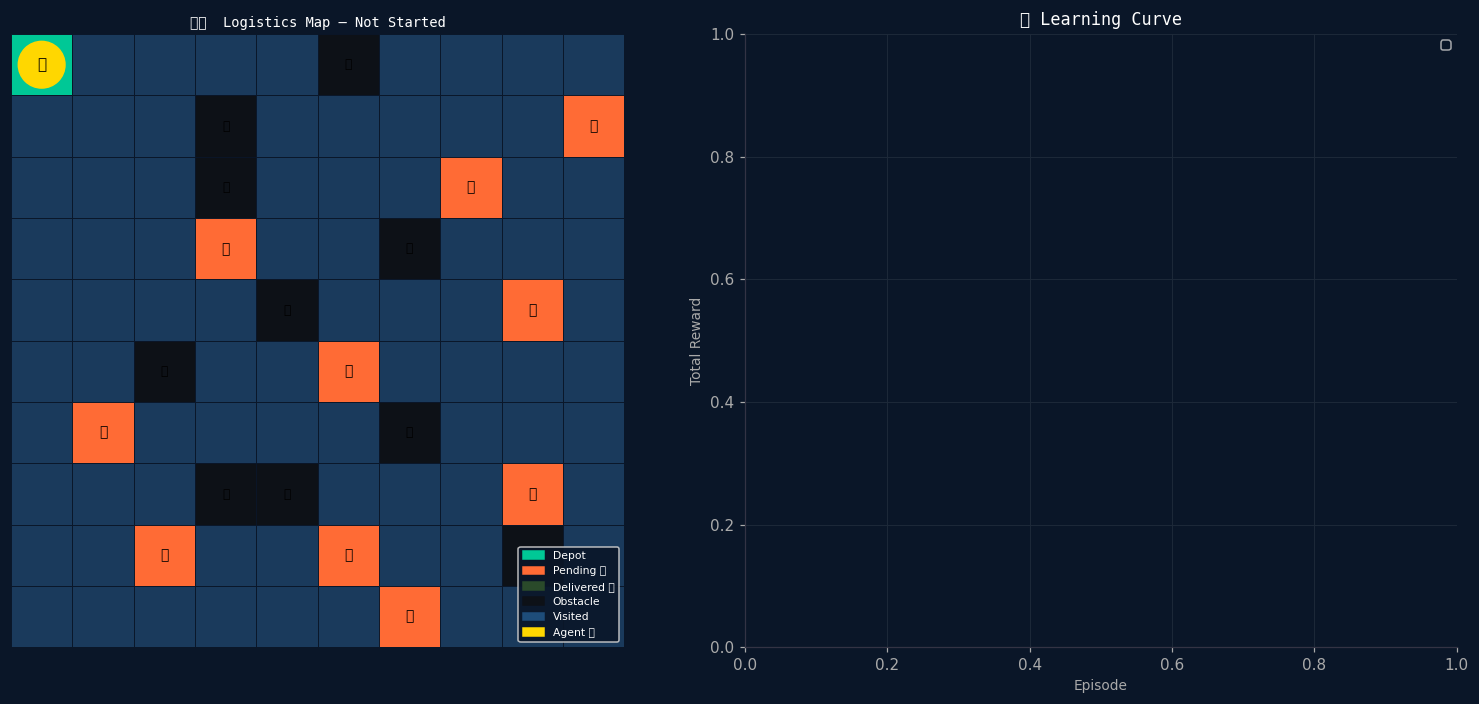

Grid: 10x10 | customers: 10 | obstacles: 10


In [7]:
# CELL 7 — Show starting map
grid  = LogisticsGrid()
frame = make_frame(grid, grid.depot, {grid.depot}, set(grid.customers),
                   [grid.depot], '🗺️  Logistics Map — Not Started', [], [])
display(IPImage(data=frame))
print(f'Grid: {GRID_SIZE}x{GRID_SIZE} | customers: {len(grid.customers)} | obstacles: {len(grid.obstacles)}')

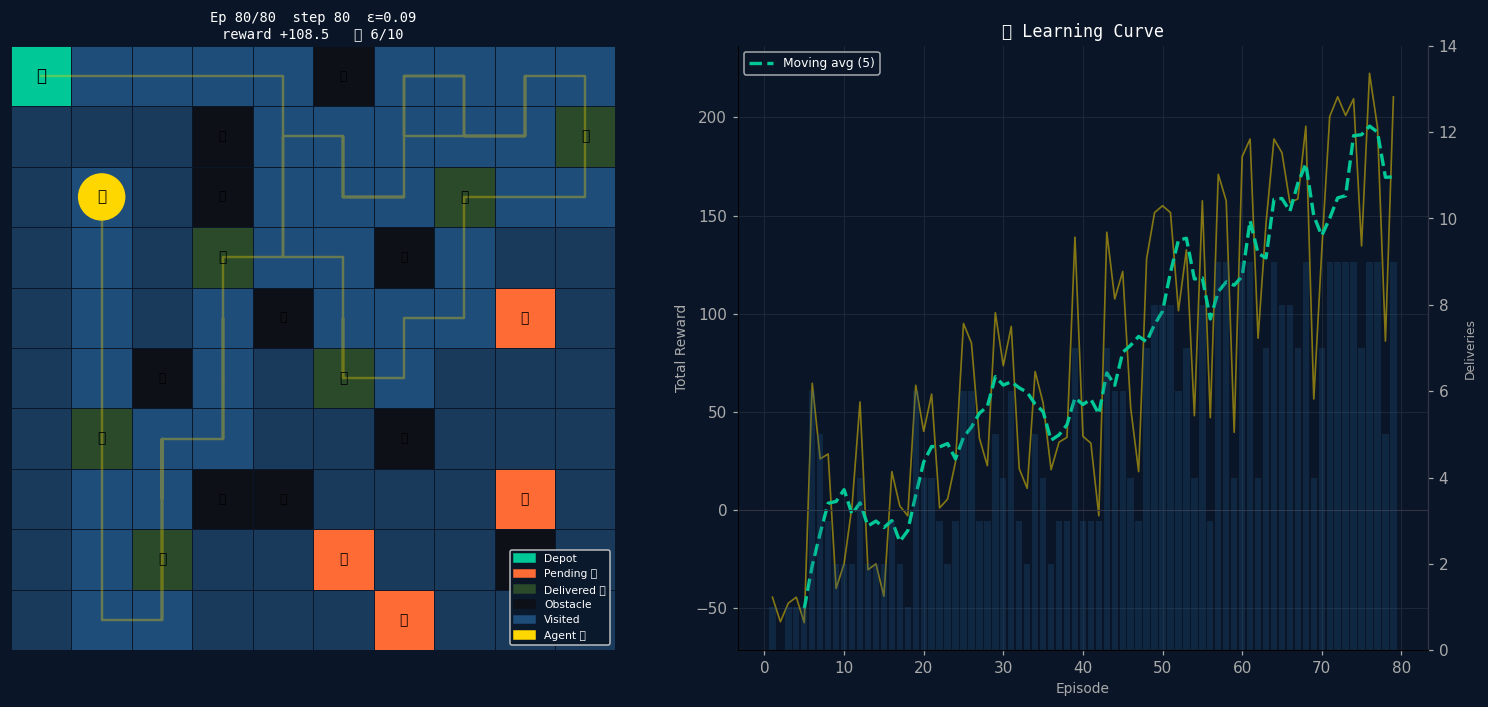


✅ Training complete!


In [8]:
# CELL 8 — TRAINING  (live step-by-step animation)
#
# Every episode the yellow agent walks the grid one step at a time.
# The frame updates after every RENDER_EVERY steps so you can watch.
# The moment all 10 deliveries are complete the episode STOPS
# and the next one begins from the depot.
# ─────────────────────────────────────────────────────────────────
print(f'Starting training — {N_EPISODES} episodes, max {MAX_STEPS} steps each.\n')

agent          = LogisticsAgent(grid)
reward_hist    = []
deliv_hist     = []

for ep in range(N_EPISODES):
    for fi, (pos, vis, rem, route, total_r, step, deliv, done) in \
            enumerate(agent.episode_frames(ep)):

        # Only render every Nth frame (or the final done frame)
        if fi % RENDER_EVERY != 0 and not done:
            continue

        status = '✅ ALL DELIVERED — DONE!' if done else f'📦 {deliv}/10'
        title  = (f'Ep {ep+1}/{N_EPISODES}  step {step}  '
                  f'ε={agent.epsilon:.2f}\n'
                  f'reward {total_r:+.1f}   {status}')

        frame = make_frame(grid, pos, vis, rem, route, title,
                           reward_hist, deliv_hist)
        clear_output(wait=True)
        display(IPImage(data=frame))
        time.sleep(DONE_SLEEP if done else FRAME_SLEEP)

    # After generator exhausts, grab stats recorded inside it
    reward_hist.append(agent.memory.rewards[-1])
    deliv_hist.append(agent.memory.deliveries[-1])

print('\n✅ Training complete!')

In [9]:
# CELL 9 — Memory analysis
mem   = agent.memory
early = mem.episodes[:10]
late  = mem.episodes[-10:]

print('='*60)
print('  AGENT MEMORY ANALYSIS')
print('='*60)
for label, group in [('First 10 episodes (untrained)', early),
                      ('Last  10 episodes (trained)',   late)]:
    print(f'\n{label}:')
    print(f'  avg reward     : {np.mean([e["reward"]     for e in group]):>8.2f}')
    print(f'  avg steps      : {np.mean([e["steps"]      for e in group]):>8.1f}')
    print(f'  avg deliveries : {np.mean([e["deliveries"] for e in group]):>8.2f} / 10')
    print(f'  avg efficiency : {np.mean([e["efficiency"] for e in group]):>8.4f}')

print(f'\nBest reward : {mem.best_reward:.2f}')
print(f'Best route  : {len(mem.best_route)} steps')
print('\nMost dangerous cells (obstacle collisions):')
for cell, n in sorted(mem.danger_hits.items(), key=lambda x:-x[1])[:5]:
    print(f'  {cell} → {n}x')
print(f'\nReward improvement : {np.mean([e["reward"] for e in late])-np.mean([e["reward"] for e in early]):+.2f}')
print(f'Steps reduction    : {np.mean([e["steps"] for e in early])-np.mean([e["steps"] for e in late]):+.1f}')

  AGENT MEMORY ANALYSIS

First 10 episodes (untrained):
  avg reward     :   -19.95
  avg steps      :     80.0
  avg deliveries :     2.20 / 10
  avg efficiency :   0.0275

Last  10 episodes (trained):
  avg reward     :   177.85
  avg steps      :     80.0
  avg deliveries :     8.10 / 10
  avg efficiency :   0.1012

Best reward : 222.50
Best route  : 81 steps

Most dangerous cells (obstacle collisions):
  (1, 3) → 68x
  (0, 5) → 66x
  (2, 3) → 48x
  (5, 2) → 40x
  (3, 6) → 38x

Reward improvement : +197.80
Steps reduction    : +0.0


In [10]:
# CELL 10 — Full evaluation dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0a1628')
fig.suptitle('Logistics Agent — Full Evaluation Dashboard',
             color='white', fontsize=14, fontfamily='monospace', y=1.01)

xs = list(range(1, N_EPISODES+1))

def sax(ax, title, xl, yl):
    ax.set_facecolor('#0a1628')
    ax.set_title(title,color='white',fontsize=11,fontfamily='monospace')
    ax.set_xlabel(xl,color='#aaa',fontsize=9); ax.set_ylabel(yl,color='#aaa',fontsize=9)
    ax.tick_params(colors='#aaa')
    ax.spines['bottom'].set_color('#334'); ax.spines['left'].set_color('#334')
    ax.spines['top'].set_visible(False);   ax.spines['right'].set_visible(False)
    ax.grid(True,color='#1e2a3a',linewidth=0.7)

# 1 reward
ax=axes[0][0]
ax.plot(xs,mem.rewards,color='#FFD700',alpha=0.45,linewidth=1)
ax.plot(xs,pd.Series(mem.rewards).rolling(8).mean(),color='#FFD700',linewidth=2.5,label='MA8')
ax.fill_between(xs,mem.rewards,alpha=0.07,color='#FFD700')
sax(ax,'Total Reward / Episode','Episode','Reward')
ax.legend(facecolor='#0a1628',labelcolor='white',fontsize=8)

# 2 steps
ax=axes[0][1]
ax.plot(xs,mem.steps,color='#ff6b35',alpha=0.45,linewidth=1)
ax.plot(xs,pd.Series(mem.steps).rolling(8).mean(),color='#ff6b35',linewidth=2.5,label='MA8')
sax(ax,'Steps / Episode','Episode','Steps')
ax.legend(facecolor='#0a1628',labelcolor='white',fontsize=8)

# 3 deliveries
ax=axes[0][2]
ax.bar(xs,mem.deliveries,
       color=['#00c896' if d==10 else '#1e6a9f' for d in mem.deliveries],
       alpha=0.85,width=0.8)
ax.axhline(10,color='#00c896',linestyle='--',linewidth=1.5,label='Target 10')
sax(ax,'Deliveries / Episode','Episode','Deliveries')
ax.legend(facecolor='#0a1628',labelcolor='white',fontsize=8)

# 4 efficiency
ax=axes[1][0]
eff=[d/max(s,1) for d,s in zip(mem.deliveries,mem.steps)]
ax.plot(xs,eff,color='#b8a4ff',alpha=0.45,linewidth=1)
ax.plot(xs,pd.Series(eff).rolling(8).mean(),color='#b8a4ff',linewidth=2.5)
sax(ax,'Efficiency (Deliveries/Steps)','Episode','Efficiency')

# 5 early vs late
ax=axes[1][1]
labels=['Avg Reward','Avg Steps','Avg Deliveries']
ev=[np.mean([e['reward'] for e in early]),np.mean([e['steps'] for e in early]),np.mean([e['deliveries'] for e in early])]
lv=[np.mean([e['reward'] for e in late]), np.mean([e['steps'] for e in late]), np.mean([e['deliveries'] for e in late])]
mx=[max(abs(ev[i]),abs(lv[i]))+1e-9 for i in range(3)]
xi=np.arange(3); w=0.35
ax.bar(xi-w/2,[v/m for v,m in zip(ev,mx)],w,label='First 10',color='#ff6b35',alpha=0.8)
ax.bar(xi+w/2,[v/m for v,m in zip(lv,mx)],w,label='Last 10', color='#00c896',alpha=0.8)
ax.set_xticks(xi); ax.set_xticklabels(labels,color='#aaa',fontsize=9)
sax(ax,'Early vs Late Comparison','','Normalised')
ax.legend(facecolor='#0a1628',labelcolor='white',fontsize=8)

# 6 best route
ax=axes[1][2]; ax.set_facecolor('#0a1628')
if mem.best_route:
    S=grid.size
    bv=set(mem.best_route)
    br=set(grid.customers)
    for p in mem.best_route: br.discard(p)
    for r in range(S):
        for c in range(S):
            cell=grid.grid[r][c]; p=(r,c); y=S-1-r
            col=('#0d1117' if cell==OBSTACLE else '#00c896' if cell==DEPOT
                 else ('#ff6b35' if p in br else '#2a4a2a') if cell==CUSTOMER
                 else '#1e4d7a' if p in bv else '#1a3a5c')
            ax.add_patch(plt.Rectangle((c,y),1,1,facecolor=col,edgecolor='#0a1628',linewidth=0.6))
            if cell==DEPOT: ax.text(c+.5,y+.5,'🏭',ha='center',va='center',fontsize=10)
            elif cell==CUSTOMER: ax.text(c+.5,y+.5,'📦' if p in br else '✅',ha='center',va='center',fontsize=8)
            elif cell==OBSTACLE: ax.text(c+.5,y+.5,'⛔',ha='center',va='center',fontsize=7)
    ax.plot([c+.5 for _,c in mem.best_route],[S-1-r+.5 for r,_ in mem.best_route],
            color='#FFD70099',linewidth=1.6)
    r,c=mem.best_route[-1]
    ax.add_patch(plt.Circle((c+.5,S-1-r+.5),.38,color=AGENT_COLOR,zorder=5))
    ax.text(c+.5,S-1-r+.5,'🤖',ha='center',va='center',fontsize=9,zorder=6)
    ax.set_xlim(0,S);ax.set_ylim(0,S);ax.set_aspect('equal');ax.axis('off')
    ax.set_title(f'Best Route — {len(mem.best_route)} steps  reward {mem.best_reward:.1f}',
                 color='white',fontsize=9,fontfamily='monospace')

plt.tight_layout()
plt.savefig('agent_evaluation.png',dpi=150,bbox_inches='tight',facecolor='#0a1628')
plt.show()
print('Saved: agent_evaluation.png')

/tmp/ipykernel_902/1932023563.py:88: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_902/1932023563.py:88: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_902/1932023563.py:88: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_902/1932023563.py:88: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_902/1932023563.py:88: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_902/1932023563.py:89: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.savefig('agent_evaluation.png',dpi=150,bbox_inches='tight',facecolor='#0a1628')
/tmp/ipykernel_902/1932023563.py:89: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.savefig('age

Saved: agent_evaluation.png


In [11]:
# CELL 11 — Memory table
df = pd.DataFrame(mem.episodes)
df['reward_ma5'] = df['reward'].rolling(5).mean().round(2)
df['steps_ma5']  = df['steps'].rolling(5).mean().round(1)
print('Agent Memory Table — first 15 + last 15 episodes')
display(pd.concat([df.head(15), df.tail(15)]).drop_duplicates().style
    .background_gradient(subset=['reward'],     cmap='RdYlGn')
    .background_gradient(subset=['steps'],      cmap='RdYlGn_r')
    .background_gradient(subset=['deliveries'], cmap='Blues')
    .format({'efficiency':'{:.4f}','reward':'{:.2f}','reward_ma5':'{:.2f}'}))

Agent Memory Table — first 15 + last 15 episodes


,episode,reward,steps,deliveries,efficiency,reward_ma5,steps_ma5
0,0,-44.50,80,1,0.0125,nan,nan
1,1,-57.00,80,0,0.0000,nan,nan
2,2,-47.50,80,1,0.0125,nan,nan
3,3,-44.50,80,1,0.0125,nan,nan
4,4,-57.50,80,1,0.0125,-50.20,80.000000
5,5,64.50,80,6,0.0750,-28.40,80.000000
6,6,26.00,80,5,0.0625,-11.80,80.000000
7,7,28.50,80,3,0.0375,3.40,80.000000
8,8,-40.00,80,2,0.0250,4.30,80.000000
9,9,-27.50,80,2,0.0250,10.30,80.000000


In [12]:
# CELL 12 — KPI Summary Report
print('='*65)
print('  KPI SUMMARY — Logistics RL Agent Simulation')
print('='*65)
print(f'''
Grid          : {GRID_SIZE}x{GRID_SIZE}
Episodes      : {N_EPISODES}
Max steps/ep  : {MAX_STEPS}
Customers     : {len(grid.customers)}
Obstacles     : {len(grid.obstacles)}

Best reward   : {mem.best_reward:.2f}
Best route    : {len(mem.best_route)} steps

First 10 → Last 10 improvement:
  reward      : {np.mean([e["reward"] for e in early]):+.2f}  →  {np.mean([e["reward"] for e in late]):+.2f}
  steps       : {np.mean([e["steps"]  for e in early]):.1f}   →  {np.mean([e["steps"]  for e in late]):.1f}
  deliveries  : {np.mean([e["deliveries"] for e in early]):.2f}/10  →  {np.mean([e["deliveries"] for e in late]):.2f}/10
  efficiency  : {np.mean([e["efficiency"] for e in early]):.4f}  →  {np.mean([e["efficiency"] for e in late]):.4f}
''')
print('Most dangerous zones:')
for cell,n in sorted(mem.danger_hits.items(),key=lambda x:-x[1])[:5]:
    print(f'  {cell} : {n} collisions')
print('\n'+'='*65)
print('Done. See agent_evaluation.png for the full chart.')

  KPI SUMMARY — Logistics RL Agent Simulation

Grid          : 10x10
Episodes      : 80
Max steps/ep  : 80
Customers     : 10
Obstacles     : 10

Best reward   : 222.50
Best route    : 81 steps

First 10 → Last 10 improvement:
  reward      : -19.95  →  +177.85
  steps       : 80.0   →  80.0
  deliveries  : 2.20/10  →  8.10/10
  efficiency  : 0.0275  →  0.1012

Most dangerous zones:
  (1, 3) : 68 collisions
  (0, 5) : 66 collisions
  (2, 3) : 48 collisions
  (5, 2) : 40 collisions
  (3, 6) : 38 collisions

Done. See agent_evaluation.png for the full chart.
